In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [3]:
TestPassengerID = test["PassengerId"]

In [4]:
print(f"Train Shape : {train.shape}")
print(f"Test Shape : {test.shape}")

Train Shape : (891, 12)
Test Shape : (418, 11)


In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

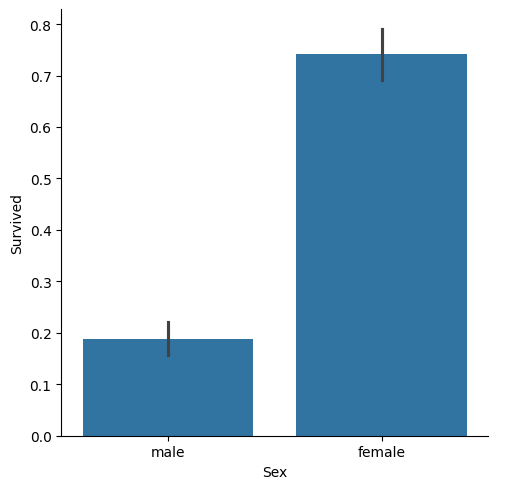

In [8]:
# The single biggest parameter in this dataset is Sex
# Females have a much much higher chance of survival than males
import seaborn as sns
sns.catplot(data=train,x="Sex",y="Survived",kind="bar")

In [9]:
gender_stats = train.groupby("Sex")["Survived"].agg(
    Total_Passengers = "count",
    Survived = "sum",
    Died = lambda x : (x==0).sum(),
    Survival_Rate = lambda x : x.mean()*100
)
print(gender_stats)

        Total_Passengers  Survived  Died  Survival_Rate
Sex                                                    
female               314       233    81      74.203822
male                 577       109   468      18.890815


In [10]:
# So always predicting females as survived itself seems like a very good choice, given all previous sophisticated 
# model_ensemble versions could only score few points better than gender_submission

# So in this model, we aim to analyse the suvived males to get a better idea of how to predict survival for males and also
# analyse the few dying females

In [11]:
survived_male = train.loc[(train["Survived"]==1) & (train["Sex"]=="male")]
dying_females = train[(train["Sex"]=="female") & (train["Survived"]==0)]

In [12]:
# Male Passenger Data
train[train["Sex"]=="male"].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,577.000000,577.000000,577.000000,453.000000,577.000000,577.000000,577.000000
mean,454.147314,0.188908,2.389948,30.726645,0.429809,0.235702,25.523893
std,257.486139,0.391775,0.813580,14.678201,1.061811,0.612294,43.138263
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,464.000000,0.000000,3.000000,29.000000,0.000000,0.000000,10.500000
75%,680.000000,0.000000,3.000000,39.000000,0.000000,0.000000,26.550000
max,891.000000,1.000000,3.000000,80.000000,8.000000,5.000000,512.329200


In [13]:
# Female Passenger Data
train[train["Sex"]=="female"].describe()
# Quite higher SibSp and Parch on average compared to male

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,314.000000,314.000000,314.000000,261.000000,314.000000,314.000000,314.000000
mean,431.028662,0.742038,2.159236,27.915709,0.694268,0.649682,44.479818
std,256.846324,0.438211,0.857290,14.110146,1.156520,1.022846,57.997698
min,2.000000,0.000000,1.000000,0.750000,0.000000,0.000000,6.750000
25%,231.750000,0.000000,1.000000,18.000000,0.000000,0.000000,12.071875
50%,414.500000,1.000000,2.000000,27.000000,0.000000,0.000000,23.000000
75%,641.250000,1.000000,3.000000,37.000000,1.000000,1.000000,55.000000
max,889.000000,1.000000,3.000000,63.000000,8.000000,6.000000,512.329200


In [14]:
survived_male.describe()
# Pclass is very close to 2

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,109.000000,109.0,109.000000,93.000000,109.000000,109.000000,109.000000
mean,475.724771,1.0,2.018349,27.276022,0.385321,0.357798,40.821484
std,244.717482,0.0,0.922774,16.504803,0.636952,0.645826,71.355967
min,18.000000,1.0,1.000000,0.420000,0.000000,0.000000,0.000000
25%,272.000000,1.0,1.000000,18.000000,0.000000,0.000000,9.500000
50%,508.000000,1.0,2.000000,28.000000,0.000000,0.000000,26.287500
75%,680.000000,1.0,3.000000,36.000000,1.000000,1.000000,39.000000
max,890.000000,1.0,3.000000,80.000000,4.000000,2.000000,512.329200


In [15]:
# From previous model analysis younger age groups had higher chances, so male chlildren could be contributing to survived_male
ages = [2,5,10,15,20]
survival_chances = []
for a in ages:
    younger_male = train.loc[(train["Sex"]=="male") & (train["Age"]<a)]
    survival_chances.append(younger_male["Survived"].mean())
    print(younger_male["Survived"].mean())
# This trend is shows just that !!

0.8
0.6521739130434783
0.59375
0.5384615384615384
0.29213483146067415


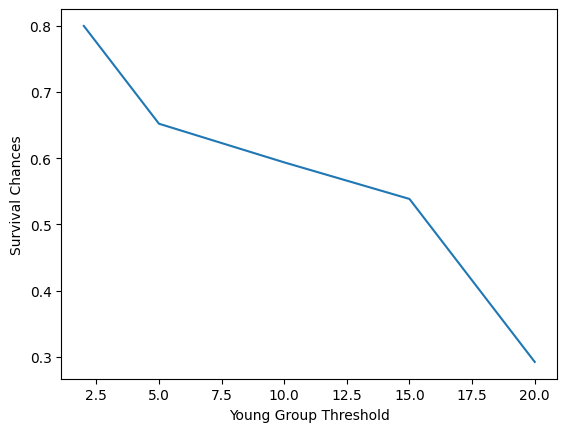

In [16]:
import matplotlib.pyplot as plt
plt.plot(ages,survival_chances)
plt.xlabel("Young Group Threshold")
plt.ylabel("Survival Chances")
plt.show()

In [17]:
dying_females.describe()
# Pclass is almost 3 !
# SibSp and Parch are > 1

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,81.000000,81.0,81.000000,64.000000,81.000000,81.000000,81.000000
mean,434.851852,0.0,2.851852,25.046875,1.209877,1.037037,23.024385
std,263.522063,0.0,0.450309,13.618591,1.814635,1.391442,24.821287
min,15.000000,0.0,1.000000,2.000000,0.000000,0.000000,6.750000
25%,206.000000,0.0,3.000000,16.750000,0.000000,0.000000,8.850000
50%,420.000000,0.0,3.000000,24.500000,1.000000,0.000000,15.245800
75%,643.000000,0.0,3.000000,33.250000,1.000000,2.000000,27.900000
max,889.000000,0.0,3.000000,57.000000,8.000000,6.000000,151.550000


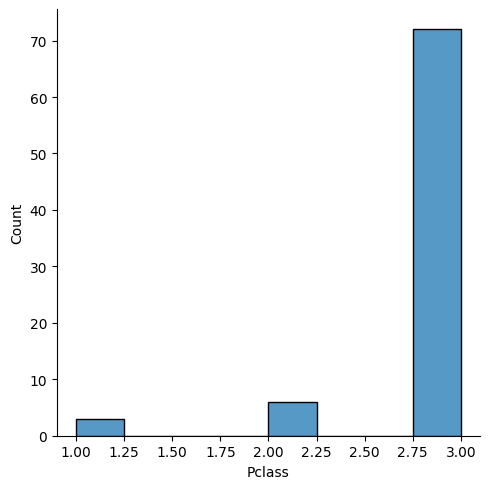

In [18]:
sns.displot(data=dying_females,x="Pclass")
# Almost all dying females are from Pclass 3

In [19]:
# Women and children from same families seem to have familiar survival states
# There are women-children with same surname in dataset (might be same families)

# Title Extraction from Name as in previous models
train['Title'] = train['Name'].str.extract(r',\s*([^\.]+)\.',expand=False)

man_titles = ["Capt", "Don", "Major", "Col", "Rev", "Dr", "Sir", "Mr", "Jonkheer"]
woman_titles = ["Dona", "the Countess", "Mme", "Mlle", "Ms", "Miss", "Lady", "Mrs"]
boy_titles = ["Master"]

# Man/Woman/Boy classification based on Titles (Boy separately since significant contribution to survive_male by young groups)
train.loc[train['Title'].isin(man_titles),'Title'] = 'man'
train.loc[train['Title'].isin(woman_titles),'Title'] = 'woman'
train.loc[train['Title'].isin(boy_titles),'Title'] = 'boy'

# Surname Extraction from Name
train['Surname'] = train['Name'].str.extract(r'^([^,]+),',expand=False)

# Mostly Women and Children survived from same families, so group out males from their surname groups into noGroup 
train.loc[train['Title'] == 'man','Surname'] = 'noGroup'

surname_counts = train['Surname'].value_counts()
train['SurnameFreq'] = train['Surname'].map(surname_counts)

# Single out alone boy/woman travellers since they dont form woman-child groups
train.loc[train['SurnameFreq'] <= 1, 'Surname'] = 'noGroup'

# Allot each surname/Woman-Child Group category their mean survival chance
train['SurnameSurvival'] = train.groupby('Surname')['Survived'].transform('mean')

print(train[train['Surname'] != 'noGroup']['SurnameSurvival'].value_counts())

SurnameSurvival
1.000000    74
0.000000    50
0.750000     8
0.142857     7
0.333333     3
Name: count, dtype: int64


In [20]:
# Most woman-child groups either survived together or died together, making this a very useful feature

# So a build up on the basic Woman-Child model built upon Gender model can be:
# 1. For males :
#         if boy :
#            Do other members of his WCG survive ? 
#                 YES : 1
#                 NO : 0
#         else :
#             0
# 2. For females :
#         Do other members of her WCG survive ? 
#             YES : 1
#             NO : 0

In [21]:
man_titles = ["Capt", "Don", "Major", "Col", "Rev", "Dr", "Sir", "Mr", "Jonkheer"]
woman_titles = ["Dona", "the Countess", "Mme", "Mlle", "Ms", "Miss", "Lady", "Mrs"]
boy_titles = ["Master"]

for df in [train,test]:
    df["Title"] = df["Name"].str.extract(r',\s*([^\.]+)\.',expand=False)

    df.loc[df["Title"].isin(man_titles),"Title"]="man"
    df.loc[df["Title"].isin(woman_titles),"Title"]="woman"
    df.loc[df["Title"].isin(boy_titles),"Title"]="boy"

    df['Surname'] = df['Name'].str.extract(r'^([^,]+),',expand=False)

    df.loc[df["Title"]=="man","Surname"]="NoGroup"

combined_surnames = pd.concat([train["Surname"],test["Surname"]])
surname_counts = combined_surnames.value_counts()

for df in [train,test]:
    df["SurnameFreq"]=df["Surname"].map(surname_counts)
    df.loc[df["SurnameFreq"]<=1,"Surname"]="NoGroup"

wcg_train = train[train["Surname"]!="NoGroup"]
wcg_survival = wcg_train.groupby("Surname")["Survived"].mean()
test["wcg_survival"] = test["Surname"].map(wcg_survival)

test["Survived"]=0

# Baseline Gender model
test.loc[test["Title"]=="woman","Survived"]=1

# Boys whose WCG members/family survived
test.loc[(test["Title"]=="boy") & (test["wcg_survival"]==1),"Survived"]=1

# Women whose WCG members/family died
test.loc[(test["Title"]=="woman") & (test["wcg_survival"]==0),"Survived"]=0

In [22]:
submission = test[['PassengerId','Survived']].copy()
submission.to_csv('wcg_submission.csv',index=False)